In [2]:
%load_ext autoreload
%autoreload 2

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
import sys
sys.path.append('../python')
import utils
import threepoint

In [6]:
from astropy.io import fits
#open_old_fits = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits')
#open_old_fits.info()

#loadnewcov = np.load('../data/dv/average_map3_796sims/map3_covariance_8arcmincut_maxn100.npy')
#open_old_fits[2].data = loadnewcov
#open_old_fits.writeto('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-24FEBRUARY2025_WITH_COV.fits')

Filename: ../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [7]:
#open_old_fits2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut-hugeIA-2.fits')
#open_old_fits2.info()

#loadnewcov = np.load('../data/dv/average_map3_796sims/map3_covariance_8arcmincut_maxn100.npy')
#open_old_fits2[2].data = loadnewcov
#open_old_fits2.writeto('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-24Feb25-8arcmincut-hugeIA-2.fits')

Filename: ../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-25Nov24-8arcmincut-hugeIA-2.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  map3          1 BinTableHDU     29   80R x 7C   [K, K, K, D, D, D, D]   
  2  COVMAT        1 ImageHDU        12   (80, 80)   float64   


In [8]:
thpt_theo_8_nobaryon = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-24FEBRUARY2025_WITH_COV.fits')
thpt_theo_huge_IA_8 = threepoint.ThreePointDataClass.from_fits('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-24Feb25-8arcmincut-hugeIA-2.fits')

In [79]:
open_to_see_data = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-24FEBRUARY2025_WITH_COV.fits')
data = np.zeros(80)
for i in range(80):
    data[i] = open_to_see_data[1].data[i][6]
cov = open_to_see_data[2].data

In [78]:
open_to_see_data2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits')
data2 = np.zeros(80)
for i in range(80):
    data2[i] = open_to_see_data2[1].data[i][6]
cov2 = open_to_see_data2[2].data

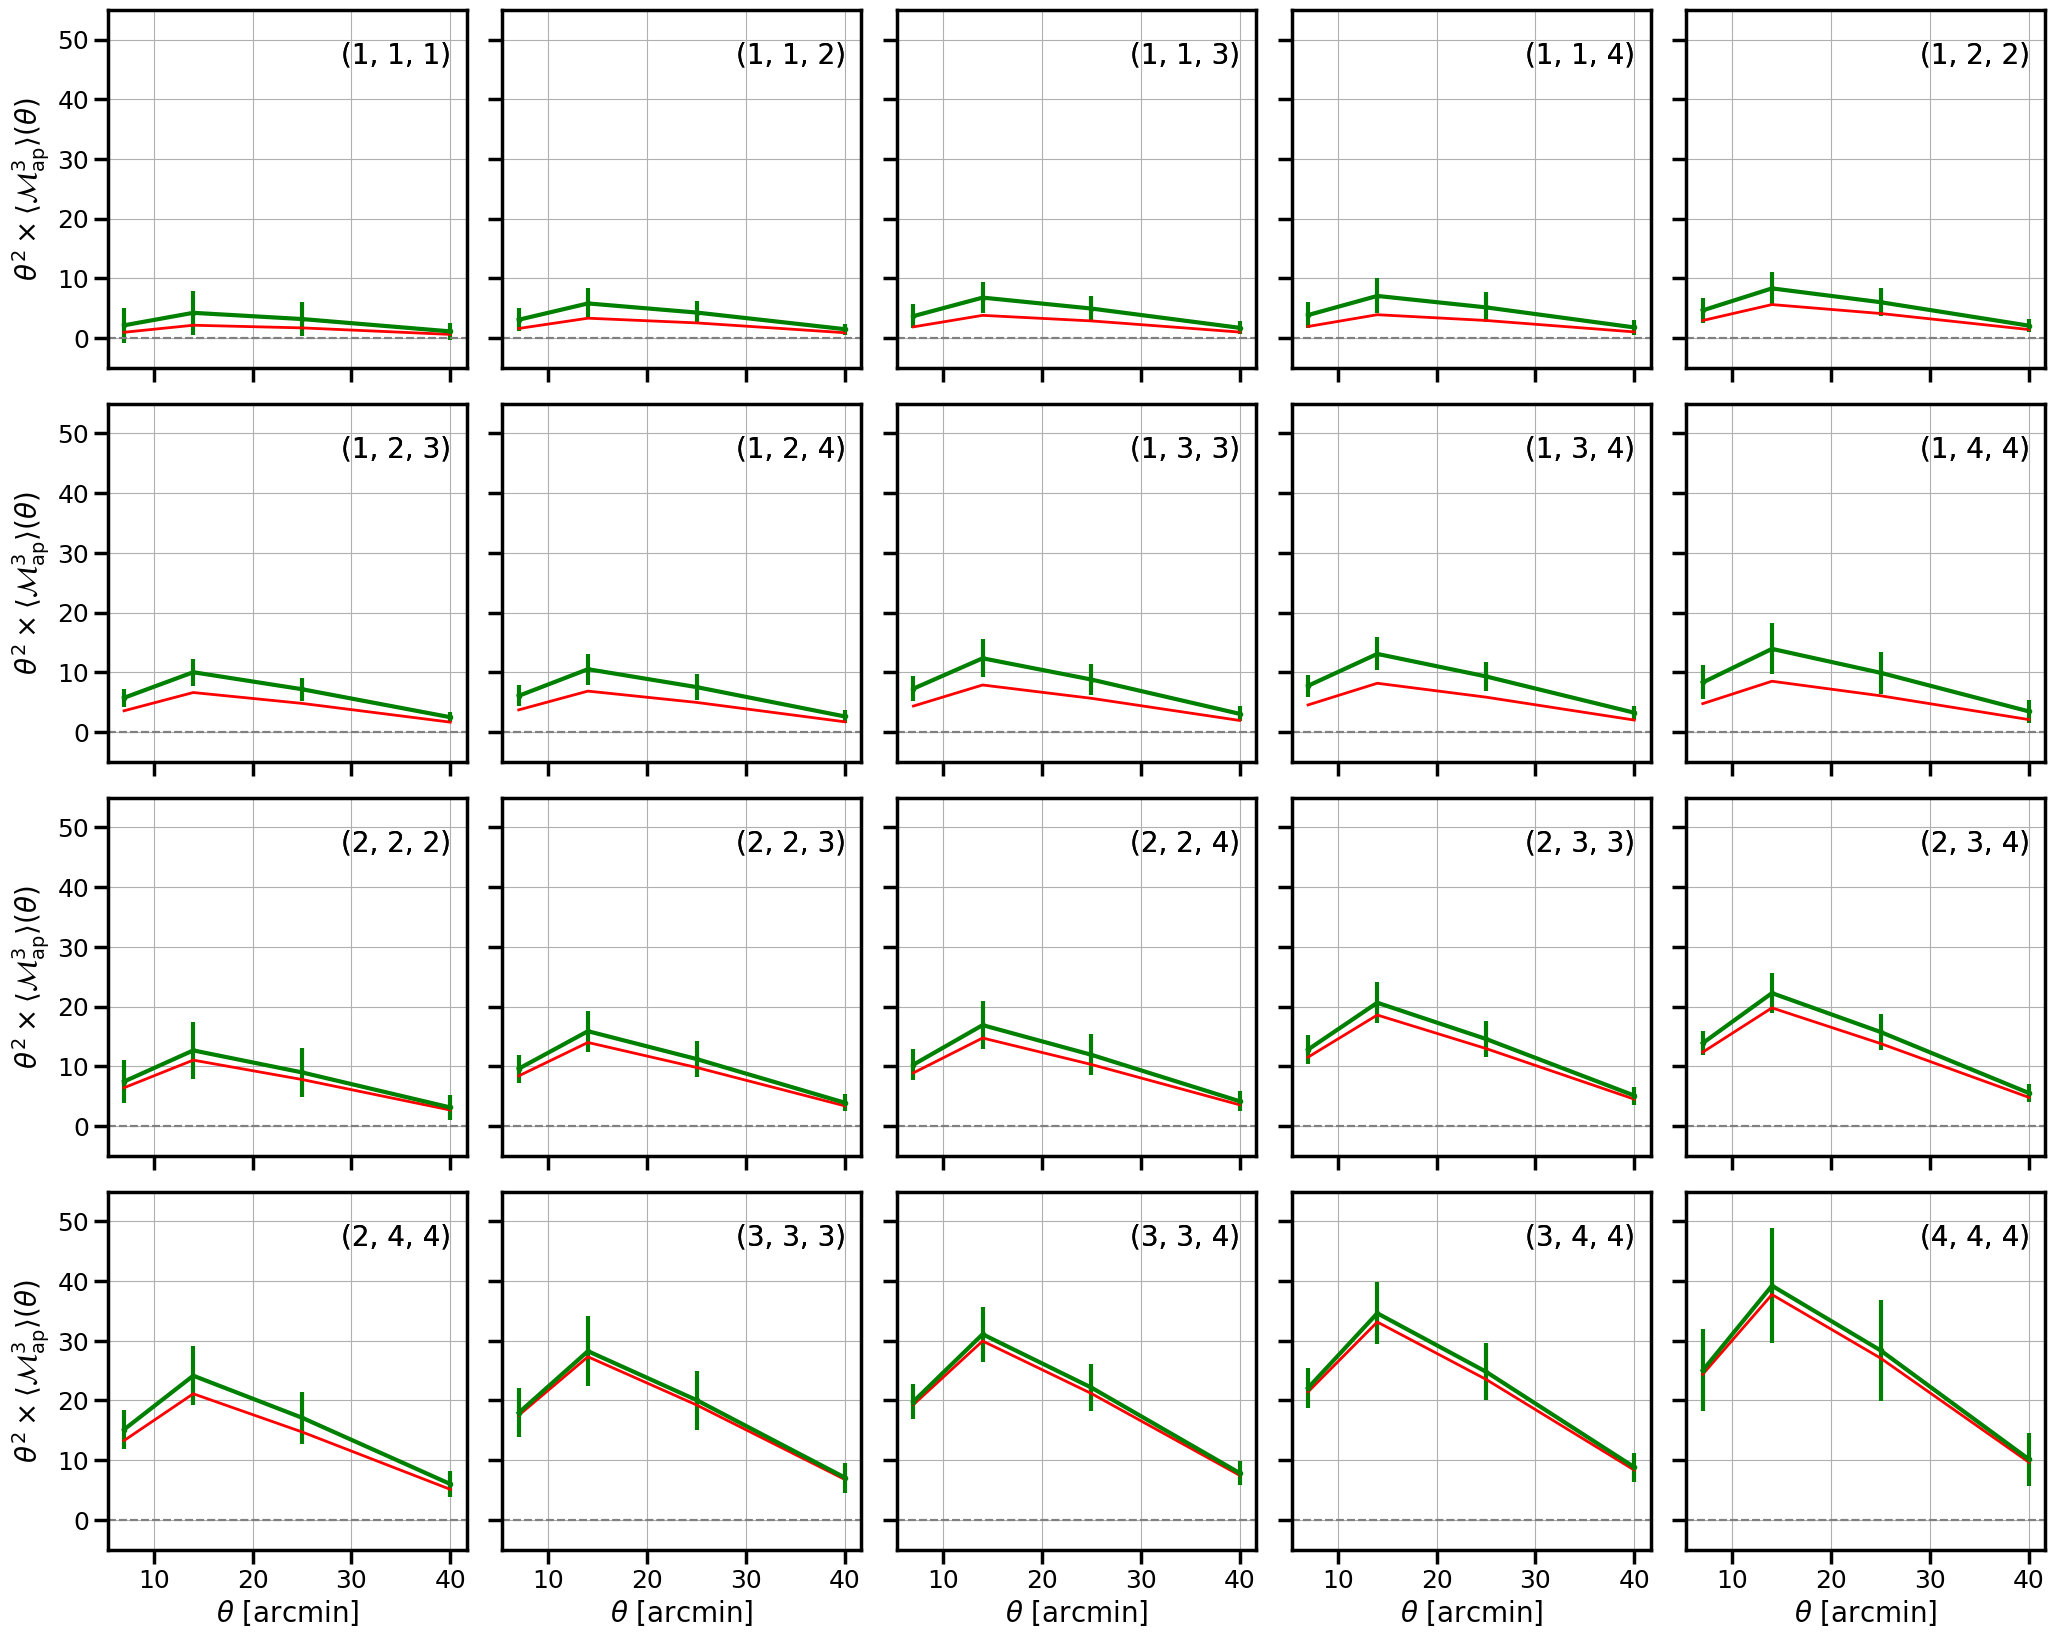

In [56]:
line_args4 = dict(color='g', lw=3, ls='-')
fig, axes = thpt_theo_8_nobaryon.plot2d(4, 5, figsize=(25, 20), **line_args4)

line_args5 = dict(color='r', lw=2, ls='-')
fig, axes = thpt_theo_huge_IA_8.plot2d(4, 5, figaxes=(fig, axes), ebar=False, **line_args5)

# Loop over axes and apply styling
for ax in axes.flatten():
    ax.grid(True)
    ax.set_ylim(-5, 55)

    # Make borders (spines) thicker
    for spine in ax.spines.values():
        spine.set_linewidth(2.5)  # Adjust the linewidth as needed

    # Make ticks larger and thicker
    ax.tick_params(axis='both', which='major', labelsize=18, width=2.5, length=10)  # Larger major ticks
    ax.tick_params(axis='both', which='minor', labelsize=16, width=1.5, length=5)   # Minor ticks (optional)

plt.show()
#plt.savefig("Mass_aperture_data_vector_24Feb25.pdf", dpi=600)

In [12]:
#Compute the signal-to-noise: total and per bin

def total_signal_to_noise(data_vector, covariance_matrix):
    """Computes the total signal-to-noise ratio for the full data vector and covariance matrix."""
    inv_cov = np.linalg.inv(covariance_matrix)
    sn_total_squared = data_vector.T @ inv_cov @ data_vector
    return np.sqrt(sn_total_squared)

def sectionwise_signal_to_noise(data_vector, covariance_matrix, section_size=4):
    """Computes the signal-to-noise ratio for each section of the data vector and covariance matrix."""
    num_sections = len(data_vector) // section_size
    sn_sections = []
    
    for i in range(num_sections):
        start_idx = i * section_size
        end_idx = start_idx + section_size
        
        data_section = data_vector[start_idx:end_idx]
        cov_section = covariance_matrix[start_idx:end_idx, start_idx:end_idx]
        
        inv_cov_section = np.linalg.inv(cov_section)
        sn_section_squared = data_section.T @ inv_cov_section @ data_section
        sn_sections.append(np.sqrt(sn_section_squared))
    
    return sn_sections

In [13]:
print(sectionwise_signal_to_noise(data,cov))

[1.0368802350653679, 2.0237017313642403, 2.2209714104407308, 2.124828580170197, 2.5345584972179047, 3.7026461173059215, 3.4498007615881323, 3.574344443218595, 4.1851585965301075, 2.9708219608504853, 2.2779450752060173, 3.999194569147039, 3.7505943391522236, 5.140749247091193, 5.877937352213237, 4.333998704347779, 4.388745457064033, 6.285534185483302, 6.164208759185203, 3.660507559472084]


In [81]:
print(total_signal_to_noise(data, cov))
print(total_signal_to_noise(data2, cov2))

8.885697604573986
9.122321894770206


In [19]:
check_diag = np.diag(cov)

for_cov2 = fits.open('../data/dv/sim_map3_emu-NLA-cosmoCosmogrid-02DECEMBER_WITH_COV.fits')
cov2 = for_cov2[2].data

check_diag2 = np.diag(cov2)

In [39]:
print(check_diag/check_diag2)

[0.96172063 0.99051027 1.0675145  1.01694998 0.96950314 0.96199674
 0.93952796 1.05102568 1.05220916 0.99575704 1.02701425 0.99177515
 1.02489791 1.04879188 1.04909258 1.02306825 1.02426521 0.98981987
 0.99823175 1.0175637  0.99663588 0.91682295 0.99519479 1.04875371
 1.02181318 1.09389973 1.04565795 0.95176054 0.99646765 1.03923192
 0.96698887 1.02581345 0.96398607 1.05700736 1.07994696 1.02256469
 1.06198438 1.00249711 1.0564941  0.98967761 0.98042363 1.00266528
 0.95430281 0.96564936 1.01065234 1.00213602 1.01458181 0.93844327
 1.01956228 0.96546916 1.01951141 0.95711043 0.96855002 0.96395131
 0.93380916 1.05676549 1.00709402 1.05616897 1.05435208 1.06363757
 0.95989153 1.01892    1.01135639 1.00783873 1.01158322 0.99826393
 0.97904994 1.02757115 1.01755577 1.02805841 0.94771035 0.97384487
 0.98627556 1.02875693 1.02140655 1.00393854 0.96333393 1.02113694
 0.93191014 0.9639154 ]


In [20]:
def hartlap(ns,nd):
    return((ns-nd-2)/(ns-1))

In [21]:
def dschneider(ns, nd, np):
    num = (nd-np)*(ns-nd-2)
    den = (ns-nd-4)*(ns-nd-1)
    tot = 1 + num/den
    return(tot**(-1))

In [55]:
print(hartlap(796,96)*dschneider(796,96,16))
print(hartlap(500,96))
print(hartlap(500,96)*dschneider(500,96,16))

0.7875894127211331
0.8056112224448898
0.6716204440324589


In [48]:
inv_adj_1 = hartlap(796,80)*dschneider(796,80,16)*np.linalg.inv(cov)

In [44]:
inv_adj_1 = hartlap(500,80)*dschneider(500,80,16)*np.linalg.inv(cov2)

In [49]:
inv_adj_2 = hartlap(500,80)*np.linalg.inv(cov2)

In [50]:
inv_diag = np.diag(inv_adj_1)
inv_diag_2 = np.diag(inv_adj_2)

[0.99338341 0.91961616 0.86582837 0.90058751 0.88040637 0.90821062
 0.90791111 0.85902539 0.8978752  0.92419188 0.84432076 0.92301262
 0.93076684 0.88264621 0.87473522 0.88826028 0.88573849 0.88483188
 0.85210497 0.83002782 0.89326124 0.94651494 0.95619793 0.94195444
 0.86964557 0.85280773 0.89016111 0.97913049 0.89924625 0.91362876
 1.02777941 0.95211879 0.98927197 0.98100122 0.91479857 0.95544005
 0.87022683 0.96310376 0.89313677 0.95658796 0.93662537 1.00803322
 0.97682015 0.89386298 0.95249621 0.8778683  0.93650278 1.01904307
 0.90574266 0.92482015 0.90606173 0.99921155 0.9231958  0.93535861
 0.9886449  0.8663189  0.96929989 0.81880138 0.88613464 0.89478632
 0.96888807 0.91837835 0.81731218 0.81449185 0.95210958 0.92344861
 0.90803266 0.92379479 0.9048492  0.93778743 0.97138164 0.98058436
 0.93918493 0.8337017  0.93670174 0.99954289 0.91126053 0.83793978
 0.93529601 0.89708414]


(array([ 5.,  4.,  7., 14., 12., 15.,  8.,  7.,  5.,  3.]),
 array([0.81449185, 0.83582061, 0.85714936, 0.87847812, 0.89980688,
        0.92113563, 0.94246439, 0.96379314, 0.9851219 , 1.00645066,
        1.02777941]),
 <BarContainer object of 10 artists>)

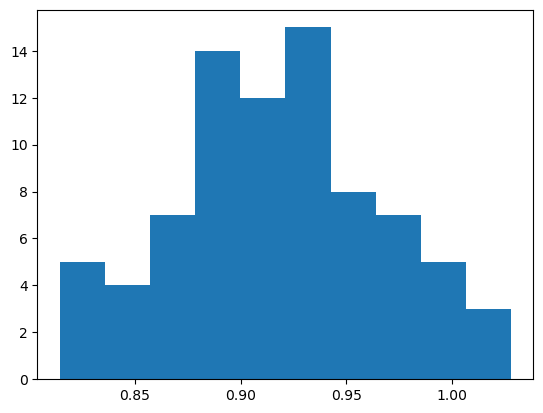

In [53]:
ratio = inv_diag/inv_diag_2
print(ratio)
plt.hist(ratio)

In [70]:
fullcov796 = np.load('../data/dv/average_map3_796sims/xip_xim_map3_covariance_8ARCMINCUT_24Feb25.npy')[400:,400:]
fullcov500 = np.load('../data/covariance/xip_xim_map3_covariance_8ARCMINCUT_31Oct24.npy')[400:,400:]
fullcov700 = np.load('../data/dv/average_map3_796sims/xip_xim_map3_covariance_8ARCMINCUT_700SIMCOV_24Feb25.npy')[400:,400:]

In [82]:
diagratios = np.diag(fullcov700)/np.diag(fullcov500)
print(diagratios)

[0.96426008 0.95910287 1.02445261 1.02142083 0.94223672 0.94566866
 0.92493424 1.03082507 1.02382721 1.02043125 1.01594753 1.02165199
 0.98853668 1.0758814  1.0534522  1.03279249 1.03332779 1.02714941
 1.01603135 1.02665696 0.96356525 0.94036269 1.01357834 1.0568931
 1.04476999 1.1078938  1.0470365  0.97301734 0.99856093 1.0713272
 0.9997024  1.01513124 0.96631968 1.063333   1.09044221 1.03546635
 1.05016835 1.00853649 1.04060044 0.99524672 1.00595142 1.01680796
 0.97778741 0.96744613 1.0072795  1.01613623 1.04143373 0.96602093
 1.03193145 0.99896407 1.05600796 1.00146976 0.94733166 0.97985233
 0.97006157 1.08572789 1.01965354 1.07546918 1.1016144  1.07826092
 0.99589629 1.04227556 1.0395052  1.00644905 1.02188605 1.0119703
 0.99294136 1.02445279 1.0250923  1.0294898  0.96891619 0.98138495
 0.98453131 1.05513175 1.02553627 1.0238512  0.98294687 1.04776611
 0.9585542  0.96755766]


In [66]:
import numpy as np
import matplotlib.pyplot as plt

def compare_covariances(cov_500, cov_800):
    # ----- Diagonal (Variance) Comparison -----
    diag_500 = np.diag(cov_500)
    diag_800 = np.diag(cov_800)
    
    print("500-sim covariance:")
    print("  Diagonal mean: {:.4e}".format(np.mean(diag_500)))
    print("  Diagonal std: {:.4e}".format(np.std(diag_500)))
    print("  Trace: {:.4e}".format(np.trace(cov_500)))
    print("  Determinant: {:.4e}".format(np.linalg.det(cov_500)))
    
    print("\n800-sim covariance:")
    print("  Diagonal mean: {:.4e}".format(np.mean(diag_800)))
    print("  Diagonal std: {:.4e}".format(np.std(diag_800)))
    print("  Trace: {:.4e}".format(np.trace(cov_800)))
    print("  Determinant: {:.4e}".format(np.linalg.det(cov_800)))
    
    # Plot histograms of the diagonal entries
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.hist(diag_500, bins=20, alpha=0.7, label='500 sims')
    plt.hist(diag_800, bins=20, alpha=0.7, label='800 sims')
    plt.xlabel("Variance Value")
    plt.ylabel("Frequency")
    plt.title("Histogram of Diagonal Entries")
    plt.legend()
    
    # ----- Eigenvalue Spectrum & Condition Number -----
    eig_500 = np.sort(np.linalg.eigvals(cov_500))
    eig_800 = np.sort(np.linalg.eigvals(cov_800))
    
    cond_500 = np.max(eig_500) / np.min(eig_500)
    cond_800 = np.max(eig_800) / np.min(eig_800)
    
    print("\nEigenvalues (sorted):")
    print("500 sims eigenvalues:\n", eig_500)
    print("800 sims eigenvalues:\n", eig_800)
    
    print("\nCondition numbers:")
    print("500 sims: {:.4e}".format(cond_500))
    print("800 sims: {:.4e}".format(cond_800))
    
    # Plot eigenvalue spectra
    plt.subplot(1, 2, 2)
    plt.plot(eig_500, 'o-', label='500 sims')
    plt.plot(eig_800, 's-', label='800 sims')
    plt.xlabel("Index")
    plt.ylabel("Eigenvalue")
    plt.title("Eigenvalue Spectrum")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # ----- Correlation Matrices -----
    def correlation_matrix(cov):
        std_dev = np.sqrt(np.diag(cov))
        return cov / np.outer(std_dev, std_dev)
    
    corr_500 = correlation_matrix(cov_500)
    corr_800 = correlation_matrix(cov_800)
    
    # Plot correlation matrices as heatmaps
    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(corr_500, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.title("500-sim Correlation Matrix")
    
    plt.subplot(1, 2, 2)
    plt.imshow(corr_800, cmap='coolwarm', vmin=-1, vmax=1)
    plt.colorbar()
    plt.title("800-sim Correlation Matrix")
    plt.tight_layout()
    plt.show()
    
    # Optionally, return a dictionary with computed metrics for further analysis
    metrics = {
        'diag_mean': (np.mean(diag_500), np.mean(diag_800)),
        'diag_std': (np.std(diag_500), np.std(diag_800)),
        'trace': (np.trace(cov_500), np.trace(cov_800)),
        'determinant': (np.linalg.det(cov_500), np.linalg.det(cov_800)),
        'eigenvalues': (eig_500, eig_800),
        'condition_number': (cond_500, cond_800)
    }
    
    return metrics

# Example usage:
# Load or define your covariance matrices as NumPy arrays.
# For example, if you saved them as .npy files:
# cov_500 = np.load("cov_500.npy")
# cov_800 = np.load("cov_800.npy")
#
# Alternatively, if you already have them in memory:
# cov_500 = your_covariance_matrix_500
# cov_800 = your_covariance_matrix_800

# Then, compare them:
# metrics = compare_covariances(cov_500, cov_800)

500-sim covariance:
  Diagonal mean: 2.0965e-19
  Diagonal std: 5.1693e-19
  Trace: 1.6772e-17
  Determinant: 0.0000e+00

800-sim covariance:
  Diagonal mean: 2.0789e-19
  Diagonal std: 5.0253e-19
  Trace: 1.6631e-17
  Determinant: 0.0000e+00

Eigenvalues (sorted):
500 sims eigenvalues:
 [1.59167312e-23 2.31967044e-23 2.58341885e-23 2.81856058e-23
 3.18916299e-23 3.73265015e-23 3.77092025e-23 5.02555193e-23
 5.48472077e-23 6.62782692e-23 7.23223323e-23 7.37921256e-23
 9.14001208e-23 9.26502915e-23 1.34682917e-22 1.59667652e-22
 1.74081765e-22 2.49024225e-22 3.37919044e-22 6.43936152e-22
 8.44595332e-22 8.64322548e-22 9.42949409e-22 1.03512278e-21
 1.12897221e-21 1.25408910e-21 1.61170617e-21 1.85626314e-21
 2.03678093e-21 2.20862844e-21 2.29901447e-21 2.73735910e-21
 2.96549010e-21 3.24914817e-21 4.48997663e-21 4.99553208e-21
 6.10486757e-21 8.35190420e-21 1.08847791e-20 1.39076041e-20
 1.72242810e-20 1.81437830e-20 2.11606488e-20 2.21578881e-20
 2.42419397e-20 2.74780486e-20 2.9011124

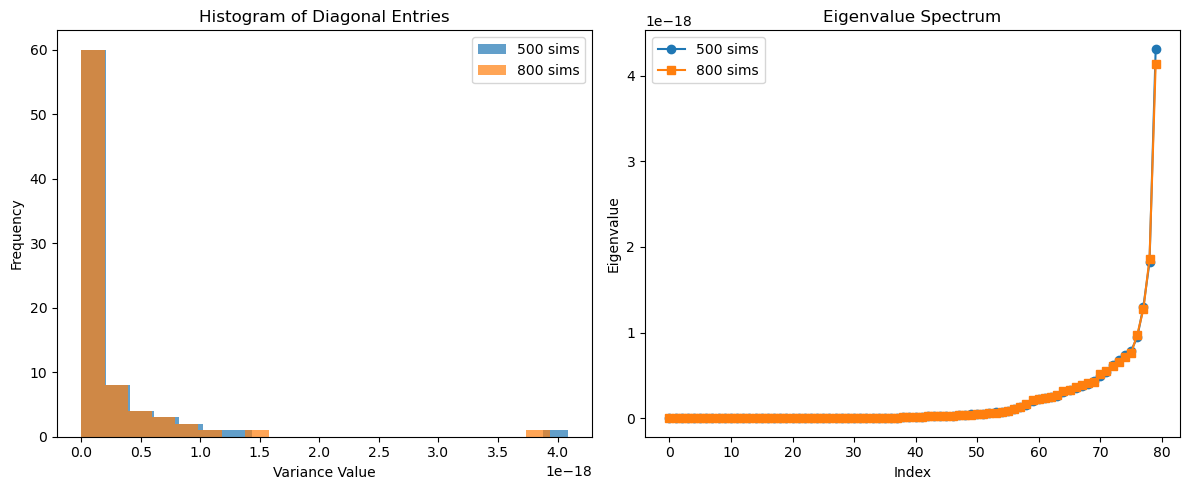

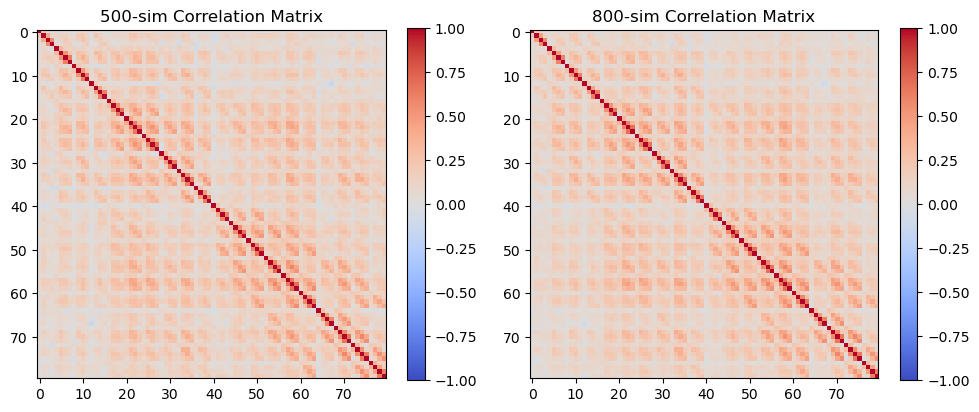

In [69]:
metrics = compare_covariances(fullcov500[400:,400:], fullcov796[400:,400:])